In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.insert(0, project_root)

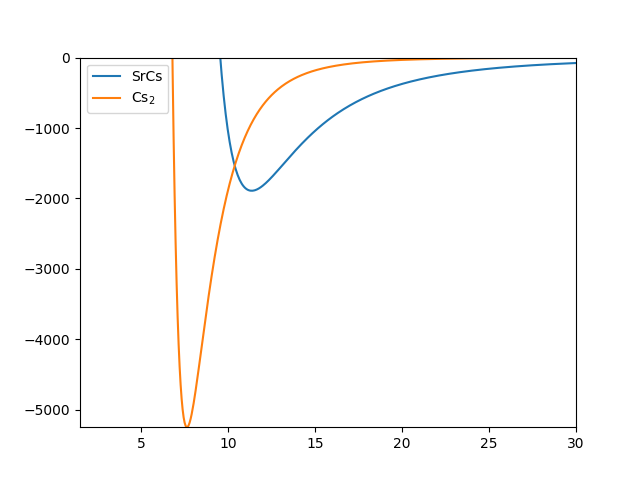

In [2]:
# Define potentials for Cs + Cs + Sr^+ 
from tbr.potentials import LJ, dLJ
from tbr.constants import ANG2BOH, K2HAR

Cs2_c6 = 6.64e+3
Cs2_c12 = 6.63e+8
SrCs_c4 = 200
SrCs_c8 = 1.67e+6

v_SrCs = LJ(n=4, m=8, cn = SrCs_c4, cm = SrCs_c8)
dv_SrCs = dLJ(n=4, m=8, cn = SrCs_c4, cm = SrCs_c8)

v_Cs2 = LJ(n=6, m=12, cn = Cs2_c6, cm = Cs2_c12)
dv_Cs2 = dLJ(n=6, m=12, cn = Cs2_c6, cm = Cs2_c12)

# N2 + N2p + He
v_funcs = (v_Cs2, v_SrCs, v_SrCs)
dv_funcs = (dv_Cs2, dv_SrCs,  dv_SrCs)

# Plot potentials
x = np.linspace(1.3, 30, 500)
plt.figure()
plt.plot(x, v_SrCs(x)/K2HAR, label = f'SrCs')
plt.plot(x, v_Cs2(x)/K2HAR, label = f'Cs$_2$')
plt.xlim(1.5, 30)
# plt.ylim(min(v_SrCs(x))/K2HAR, 1e-2) # SrCs
plt.ylim(min(v_Cs2(x))/K2HAR, 1e-2) # Cs2
# plt.ylim(min(v_N2He(x))/K2HAR, 1e-2) # N2He
plt.legend()
plt.show()

In [3]:
masses = (132.91, 132.91, 87.62) # Cs, Cs, Sr+
m1, m2, m3 = masses
E0 = 1 # Kelvin
R0 = 2000.0
b0 = 0

In [4]:
# Simulate one trajectory
from tbr.simulator import run_trajectory_worker
import time

seed = int(np.random.random()*8923)
print(f'Running trajectory with seed {seed}...')
task_data = m1, m2, m3, E0, b0, R0, v_funcs, dv_funcs, seed
t0 = time.time()
solution = run_trajectory_worker(task_data=task_data)
tf = time.time()
print(f'Trajectory run in {tf-t0} s')

Running trajectory with seed 5100...
Energy drift 3.5723103450769744e-12 Hartree
Trajectory run in 8.229233503341675 s


Result (n12, n23, n41, nd, nc): [0 0 0 1 0]


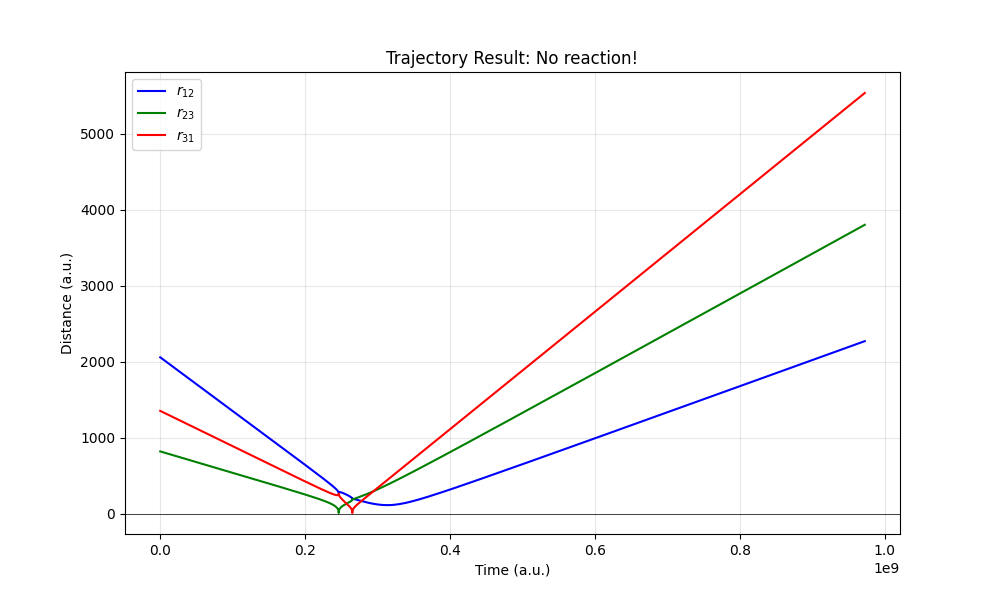

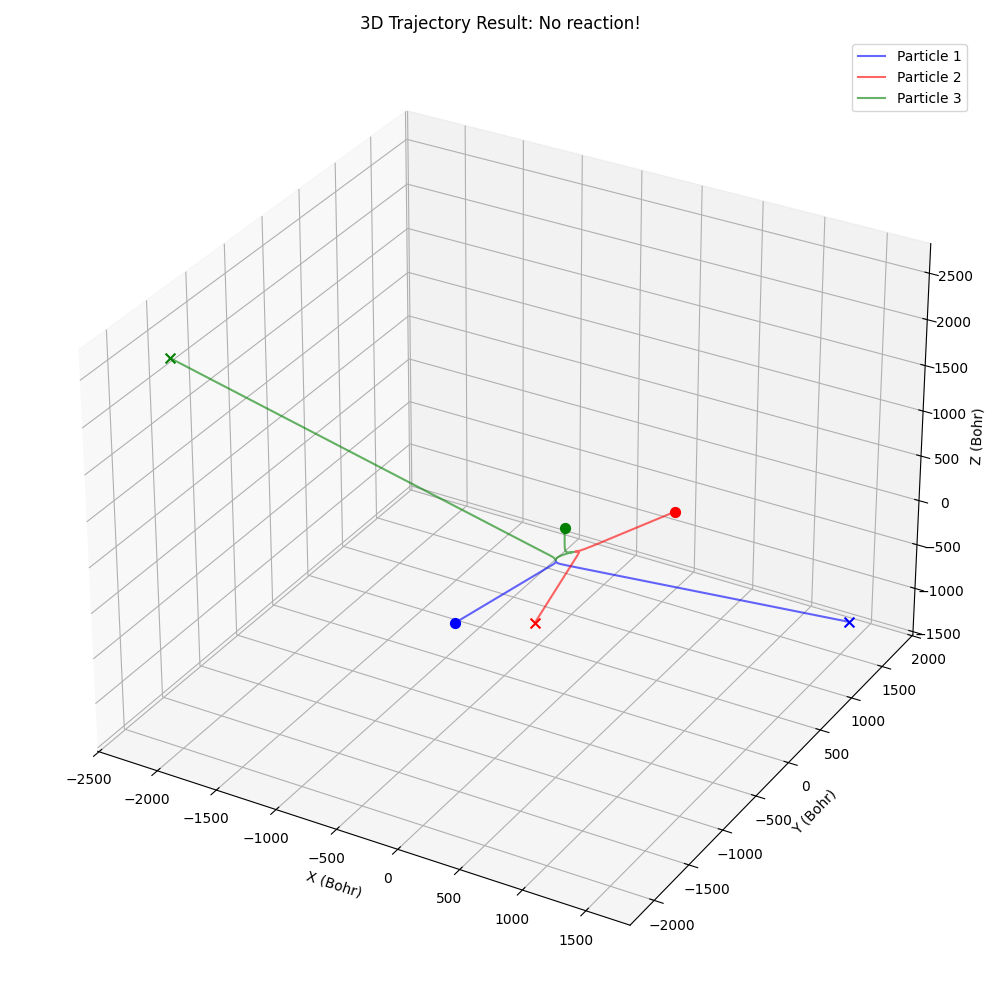

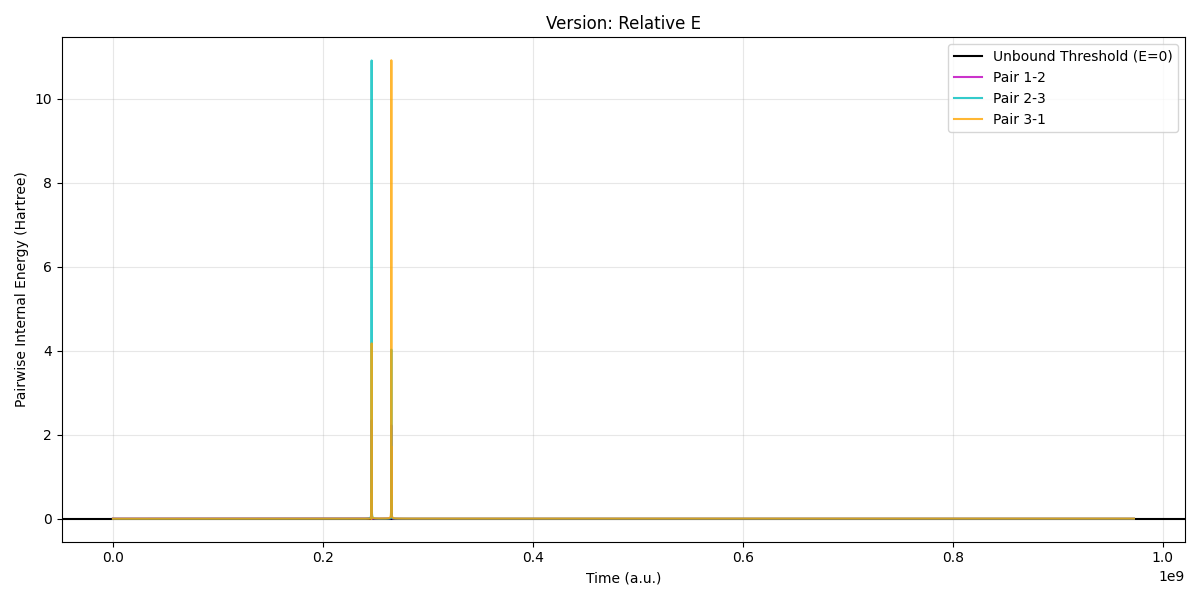

In [7]:
# Plot
from tbr.simulator import get_distances_from_solution
from tbr.plotters import plot_distances, plot_3d_motion, plot_relative_e

# Observables
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']

r12, r23, r31 = get_distances_from_solution(
            np.vstack([rho_vec, p_vec]), m1, m2
        )

# data_block = np.vstack([
#             solution['times'], 
#             r12, r23, r31,
#             solution['positions_rho'], 
#             solution['momenta_p']
#         ]).T

print(f'Result (n12, n23, n41, nd, nc): {n_res}')
plot_distances(solution, masses)
# plot_3d_motion(data_block, m1, m2, m3, seed)
plot_3d_motion(solution, masses)
plot_relative_e(solution, masses, v_funcs)
# plt.show()

Running trajectory with seed 31536...
Energy drift 1.381665450165382e-11 Hartree
Trajectory run in 4.9665069580078125 s
Result (n12, n23, n31, nd, nc): [0 0 1 0 0]


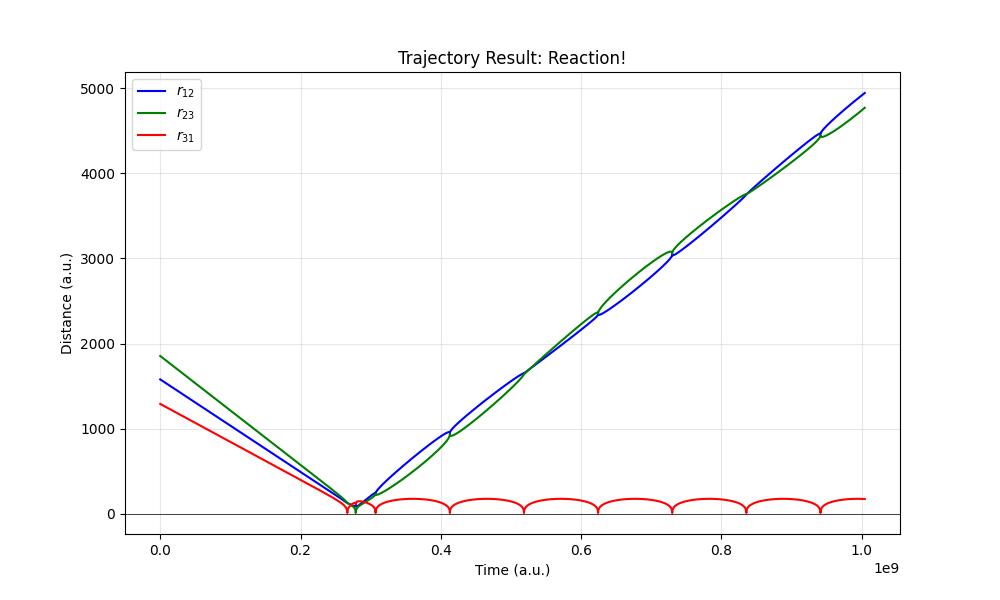

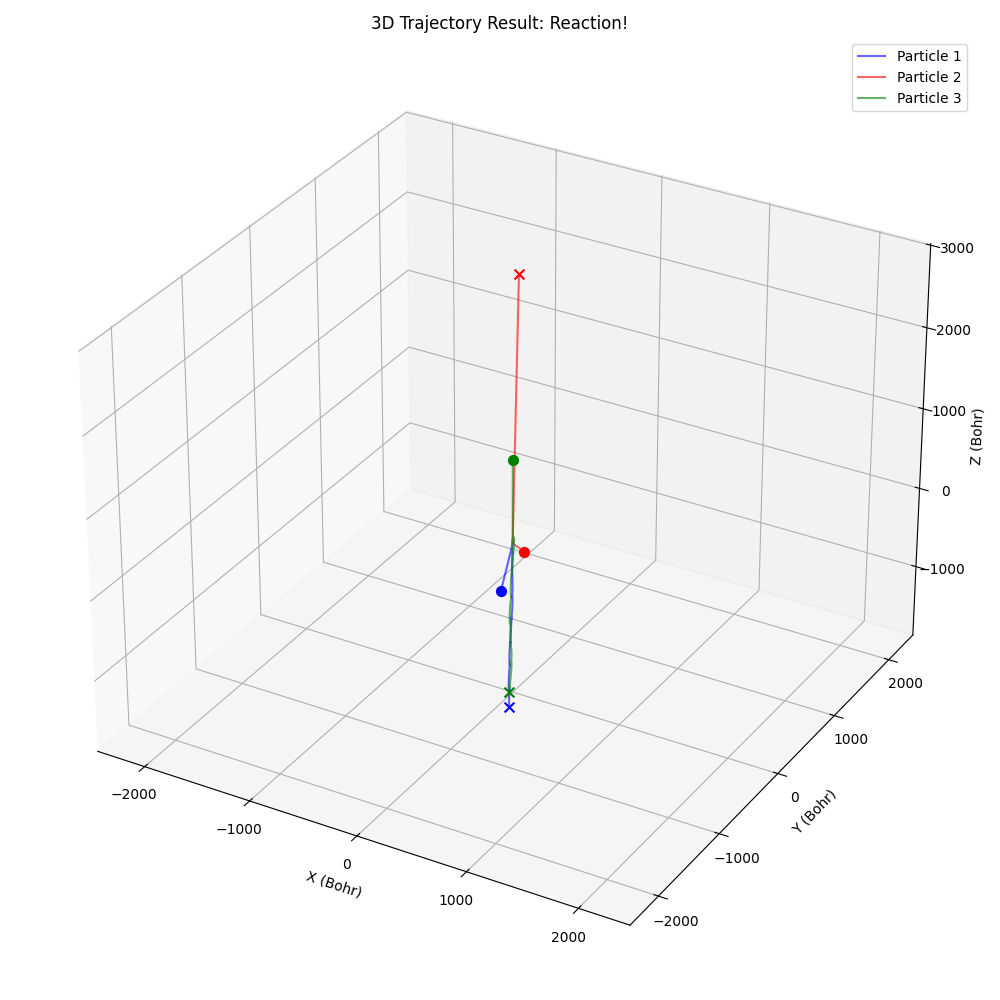

In [8]:
# Simulate until a reaction is found. 
def run_t():
    seed = int(np.random.random()*8923) + 23013
    print(f'Running trajectory with seed {seed}...')
    task_data = m1, m2, m3, E0, b0, R0, v_funcs, dv_funcs, seed
    t0 = time.time()
    solution = run_trajectory_worker(task_data=task_data)
    tf = time.time()
    print(f'Trajectory run in {tf-t0} s')
    
    return solution

solution = run_t()
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']
n_t = 0

while (n_res[3] == 1) & (n_t < 100): # search for non-dissociative trajectories 
    solution = run_t()
    n_res = solution['n_res']
    rho_vec = solution['positions_rho']
    p_vec = solution['momenta_p']
    n_t+=1


if solution['success'] == True:
    r12, r23, r31 = get_distances_from_solution(
                np.vstack([rho_vec, p_vec]), m1, m2
            )

    data_block = np.vstack([
                solution['times'], 
                r12, r23, r31,
                solution['positions_rho'], 
                solution['momenta_p']
            ]).T
    print(f'Result (n12, n23, n31, nd, nc): {n_res}')
    plot_distances(solution, masses)
    plot_3d_motion(solution, masses)
    # plot_relative_e(solution, masses, v_funcs)

In [5]:
# Full calculation
from tbr.simulator import run_b_scan

E0 = 1e-3
R0 = 4000
b_values = [0,100]
try:
    run_b_scan(
        b_range=b_values, num_traj_per_b=10,
        masses=masses, E0=E0, R0=R0, v_funcs=v_funcs,
        dv_funcs=dv_funcs,
        summary_file='sample_results_SrCs.csv',
        save_detailed=False
    )
except RuntimeError as e:
    print(f'Multiprocessing error: {e}')


Starting Scan over b0: [0, 100]
Summary will be saved to: sample_results_SrCs.csv

--- Running batch for b0 = 0.00 ---

--- Total rejections due to V(R0) > 0.01*E0 for b0=0: 3 ---
Rejected: V(R0) > 0.01*E0, increase R0.
Rejected: V(R0) > 0.01*E0, increase R0.
Rejected: V(R0) > 0.01*E0, increase R0.
Reaction found at E: 1.00e-03 K, b: 0.00 a0, seed: 74910631
Reaction found at E: 1.00e-03 K, b: 0.00 a0, seed: 20639055
Reaction found at E: 1.00e-03 K, b: 0.00 a0, seed: 98194798
  Finished b0=0.00. Runtime: 38.61s. Rej: 3
  Stats: n12=0, n23=1, n31=2, nd=4, nc=0

--- Running batch for b0 = 100.00 ---

--- Total rejections due to V(R0) > 0.01*E0 for b0=100: 2 ---
Rejected: V(R0) > 0.01*E0, increase R0.
Rejected: V(R0) > 0.01*E0, increase R0.
Reaction found at E: 1.00e-03 K, b: 100.00 a0, seed: 39695475
Reaction found at E: 1.00e-03 K, b: 100.00 a0, seed: 13663929
  Finished b0=100.00. Runtime: 65.88s. Rej: 2
  Stats: n12=0, n23=1, n31=1, nd=6, nc=0
b-scan complete!


In [9]:
from tbr.analysis import opacity, cross_section, rate
from tbr.constants import U2ME

in_file = 'results/SrCs_short.txt'

masses = (132.91, 132.91, 87.62) # Cs, Cs, Sr+
m1, m2, m3 = masses
mu0 = np.sqrt(m1*m2*m3/(m1+m2+m3))
m12 = m1*m2/(m1+m2)
tolerance_numerator = 10
window_size = 3
tolerances = {'AA': 10, 'AB': 38} # AA : Cs2, AB: SrCs+
windows = {'AA': 3, 'AB': 3}

opac = opacity(in_file, masses)
sigma = cross_section(opac, masses, tolerances=tolerances, windows=windows)
k3 = rate(opac, mu0, masses, windows=windows, tolerances=tolerances)

Text(0, 0.5, 'Probability (E,b)')

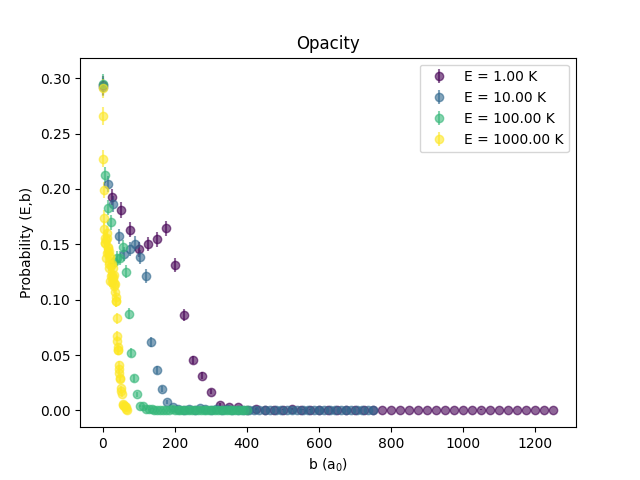

In [10]:
# Opacity plot
e_list = [1, 10, 100, 1000]
colors = plt.cm.viridis(np.linspace(0,1,len(e_list)))

plt.figure()
for i,e_val in enumerate(e_list):
    opacplt = opac[opac['e']==e_val]
    plt.errorbar(opacplt['b'], opacplt['p_AB'], opacplt['p_AB_err'], fmt = 'o', color = colors[i], alpha = 0.6, label = f'E = {e_val:.2f} K')
    plt.title('Opacity')
plt.legend()
plt.xlabel(r'b (a$_0$)')
plt.ylabel(r'Probability (E,b)')

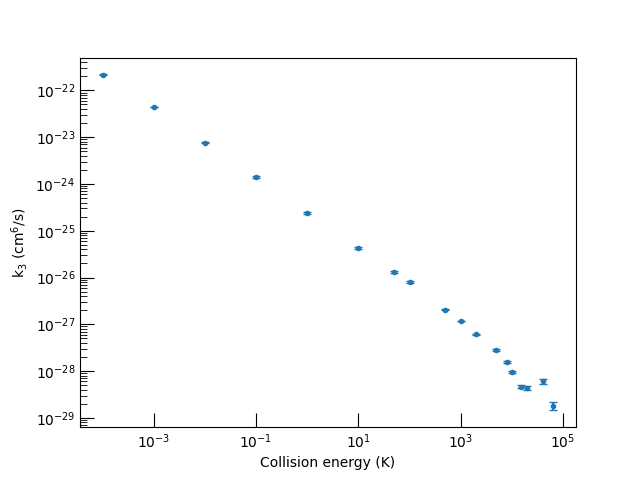

In [11]:
# Rate plot
plt.figure()
plt.errorbar(k3['e'], k3['k_AB'], k3['k_AB_err'], fmt='.', capsize=3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Collision energy (K)')
plt.ylabel('k$_3$ (cm$^6$/s)')
plt.tick_params(direction='in', which='minor', length=5)
plt.tick_params(direction='in', which='major', length=10)